In [ ]:
import pandas as pd
import os
from scipy.stats import mannwhitneyu
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font_manager.fontManager.addfont("/home/tx82/Arial.ttf")
plt.rcParams['font.family'] = 'Arial'

import sys
sys.path.append("../")

# Functions and data preparation

In [ ]:
def format_pval(pval, pval_star = False, pval_cutoff = 0.05, pval_sci = True):
    '''
    Format p value for plotting
    '''
    if pval_star == False:
        if pval >= pval_cutoff or pval is None:
            label = "n.s."
        else:
            if pval_sci == True:
                label = '{:0.1e}'.format(pval)
            else:
                label = str(round(pval, 2))
    else:
        if pval >= pval_cutoff:
            label = "n.s."
        elif pval is None or np.isnan(pval):
            label = None
        else:
            if pval == 0:
                label = "*" * 3
            elif (int('{:0.1e}'.format(pval).split("-")[1]) - 1) <= 3:
                label = "*" * (int('{:0.1e}'.format(pval).split("-")[1]) - 1)
            else:
                label = "*" * 3

    return label


In [ ]:
root_dir = "/fs/cbsuhy02/storage/tx82/"

# define all the INPUT paths
# af3 scores fro different groups (parsed using data_processing/process_af3_results.py)
our_af3_scores_file = f"{root_dir}/AD_interactome/results/Alphafold3/_all/af3_output_summary/all_af3_jobs_scores_dedup_ADNeuroNet.tsv"
opencell_af3_scores_file = f"{root_dir}/AD_interactome/results/Alphafold3/_all/af3_output_summary/all_af3_jobs_scores_opencell_controls.tsv"
pos_af3_scores_file = f"{root_dir}/AD_interactome/results/Alphafold3/_all/af3_output_summary/all_af3_jobs_scores_pos_controls.tsv"
neg_af3_scores_file = f"{root_dir}/AD_interactome/results/Alphafold3/_all/af3_output_summary/all_af3_jobs_scores_neg_controls.tsv"
rand_af3_scores_file = f"{root_dir}/AD_interactome/results/Alphafold3/_all/af3_output_summary/all_af3_jobs_scores_rand_controls.tsv"

# define all the OUTPUT paths
fig3e_file = "Fig3e.png"
# will also output FigS4

In [12]:
our_name = "ADNeuronNet"
pos_neg_name = "All PDB pairs"
pos_name = "Interacting PDB pairs"
neg_name = "Non-interacting PDB pairs"
rand_name = "Random pairs"
opencell_name = "OpenCell interactions"

# 1) load af3 scores for our interactome
our_af3_scores = pd.read_table(our_af3_scores_file, sep="\t")
our_af3_scores = our_af3_scores[["af3_job_name", "ppi", "iptm", "ptm", "ranking_score"]]
our_af3_scores["group"] = our_name  
print("Number of ppis in AD interactome:", len(our_af3_scores))
# 2) load af3 scores for OpenCell interactions
opencell_af3_scores = pd.read_table(opencell_af3_scores_file, sep="\t")
opencell_af3_scores = opencell_af3_scores[["af3_job_name", "ppi", "iptm", "ptm", "ranking_score"]]
opencell_af3_scores["group"] = opencell_name
print("Number of OpenCell interactions:", len(opencell_af3_scores))
# 3) load af3 scores for positive controls (in the same pdb co-complex, direct interaction)
pos_af3_scores = pd.read_table(pos_af3_scores_file, sep="\t")
pos_af3_scores = pos_af3_scores[["af3_job_name", "ppi", "iptm", "ptm", "ranking_score"]]
pos_af3_scores["group"] = pos_name
print("Number of positive controls (in the same pdb co-complex, direct interaction):", len(pos_af3_scores))
# 4) load af3 scores for negative controls (in the same pdb co-complex, non-direct interaction)
neg_af3_scores = pd.read_table(neg_af3_scores_file, sep="\t")
neg_af3_scores = neg_af3_scores[["af3_job_name", "ppi", "iptm", "ptm", "ranking_score"]]
neg_af3_scores["group"] = neg_name
print("Number of negative controls (in the same pdb co-complex, non-direct interaction):", len(neg_af3_scores))
# 5) load af3 scores for random pairs
rand_af3_scores = pd.read_table(rand_af3_scores_file, sep="\t")
rand_af3_scores = rand_af3_scores[["af3_job_name", "ppi", "iptm", "ptm", "ranking_score"]]
rand_af3_scores["group"] = rand_name
print("Number of random pairs:", len(rand_af3_scores))

all_scores = pd.concat([our_af3_scores, pos_af3_scores, neg_af3_scores, rand_af3_scores, opencell_af3_scores], axis=0)

Number of ppis in AD interactome: 1570
Number of OpenCell interactions: 540
Number of positive controls (in the same pdb co-complex, direct interaction): 562
Number of negative controls (in the same pdb co-complex, non-direct interaction): 3650
Number of random pairs: 4580


# Fig 3E - Distribution of AlphaFold3 ipTM values across different interaction datasets indicates high quality of ADNeuronNet interactions

/tmp/ipykernel_961897/1677511830.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-interacting\nPDB pairs", "Random", "OpenCell", "ADNeuronNet", "Interacting\nPDB pairs"], rotation=30, ha="right", va="top", fontsize=14)
/tmp/ipykernel_961897/1677511830.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([i.get_text() for i in ax.get_yticklabels()], fontsize=14)


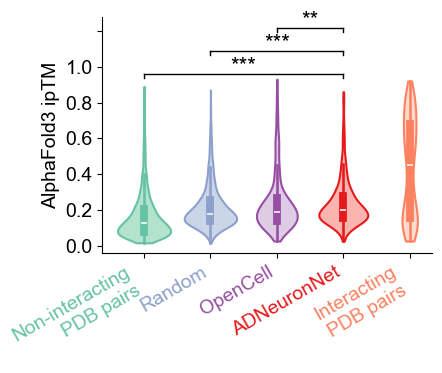

In [13]:
# Plot distribution of af3 scores for all af3 jobs 
# Fig 3e
# (compare with random pairs, positive controls - non-direct PDB pairs, negative controls - direct PDB pairs, positive+negative controls - all PDB pairs, OpenCell interactions)

# select the score column to plot
af3_score = "iptm" # or "ranking_score" 

# visualize the distribution of af3 scores for different groups with violin plot
fig, ax = plt.subplots(figsize=(4.5,3.8))
edgecolor_list = [sns.color_palette(palette="Set2")[0], sns.color_palette(palette="Set2")[2], sns.color_palette(palette="Set1")[3], 
              sns.color_palette(palette="Set1")[0], sns.color_palette(palette="Reds")[2]]
facecolor_list = [sns.color_palette(palette="Pastel2")[0], sns.color_palette(palette="Pastel2")[2], sns.color_palette(palette="Pastel1")[3], 
              sns.color_palette(palette="Pastel1")[0], sns.color_palette(palette="Reds")[0]]
label_list = [neg_name, rand_name, opencell_name, our_name, pos_name]
sns.violinplot(data=all_scores[(all_scores["group"].isin(label_list)) & (all_scores[af3_score] > 0)], x="group", y=af3_score, order=label_list, cut=0, inner="box", ax=ax)
i = 0
# color the violins
for violin in ax.collections:
    if type(violin) == matplotlib.collections.PathCollection:  # skip scatter points
        continue
    violin.set_facecolor(facecolor_list[i])  # fill color
    violin.set_edgecolor(edgecolor_list[i])  # outline color
    violin.set_linewidth(1.5)  
    i += 1
# color the boxes (quartile lines)
for j, line in enumerate(ax.lines):
    line.set_color(edgecolor_list[j // 3])
# ax.set_ylim(0, 1.15)
ax.set_xlabel("")
af3_score_dict = {"iptm": "ipTM", "ranking_score": "ranking score"}
ax.set_ylabel(f"AlphaFold3 {af3_score_dict[af3_score]}", fontsize=14)

ax.set_xticklabels(["Non-interacting\nPDB pairs", "Random", "OpenCell", "ADNeuronNet", "Interacting\nPDB pairs"], rotation=30, ha="right", va="top", fontsize=14)
# re-color the x-axis tick labels to match the violin colors
for tick_label, color in zip(ax.get_xticklabels(), edgecolor_list):
    tick_label.set_color(color)
# ax.set_yticks(np.arange(0, 1.2, 0.2))
ax.set_yticklabels([i.get_text() for i in ax.get_yticklabels()], fontsize=14)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

compare_group_list = [(our_name, neg_name), (our_name, rand_name), (our_name, opencell_name)]
y = ax.get_ylim()[1] * 0.98               
h = ax.get_ylim()[1] * 0.02               
for i,compare_groups in enumerate(compare_group_list):
    x1 = all_scores[all_scores["group"] == compare_groups[0]][af3_score]
    x2 = all_scores[all_scores["group"] == compare_groups[1]][af3_score]
    stat, pval = mannwhitneyu(x1, x2, alternative="greater")

    step = (h*3)*i*2.2
    x_left, x_right = sorted([label_list.index(compare_groups[0]), label_list.index(compare_groups[1])])
    ax.plot([x_left, x_right], [y + step, y + step], color="black", lw=1)
    ax.plot([x_left, x_left], [y + step - 0.02, y + step], color="black", lw=1)
    ax.plot([x_right, x_right], [y + step - 0.02, y + step], color="black", lw=1)
    ax.text((x_left + x_right) / 2, y + step - 0.01, format_pval(pval, pval_star=True, pval_cutoff = 0.05, pval_sci=False), ha="center", va="bottom", color="black", fontsize=16)
fig.tight_layout()
plt.savefig(fig3e_file, bbox_inches='tight', dpi=500)
plt.savefig(fig3e_file.replace(".png", ".svg"), format="svg", bbox_inches='tight', dpi=500)

/tmp/ipykernel_961897/1084689785.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-interacting\nPDB pairs", "Random", "OpenCell", "ADNeuronNet", "Interacting\nPDB pairs"], rotation=30, ha="right", va="top", fontsize=14)
/tmp/ipykernel_961897/1084689785.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([i.get_text() for i in ax.get_yticklabels()], fontsize=14)


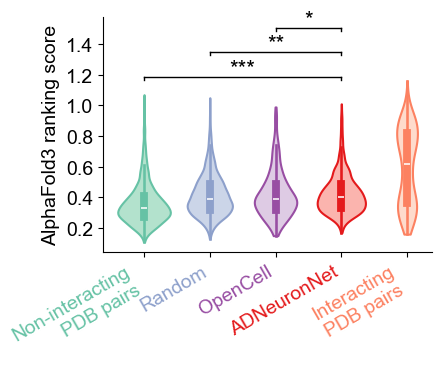

In [14]:
# Plot distribution of af3 scores for all af3 jobs 
# Fig S4
# (compare with random pairs, positive controls - non-direct PDB pairs, negative controls - direct PDB pairs, positive+negative controls - all PDB pairs, OpenCell interactions)

# select the score column to plot
af3_score = "ranking_score" # or "iptm" 

# visualize the distribution of af3 scores for different groups with violin plot
fig, ax = plt.subplots(figsize=(4.5,3.8))
edgecolor_list = [sns.color_palette(palette="Set2")[0], sns.color_palette(palette="Set2")[2], sns.color_palette(palette="Set1")[3], 
              sns.color_palette(palette="Set1")[0], sns.color_palette(palette="Reds")[2]]
facecolor_list = [sns.color_palette(palette="Pastel2")[0], sns.color_palette(palette="Pastel2")[2], sns.color_palette(palette="Pastel1")[3], 
              sns.color_palette(palette="Pastel1")[0], sns.color_palette(palette="Reds")[0]]
label_list = [neg_name, rand_name, opencell_name, our_name, pos_name]
sns.violinplot(data=all_scores[(all_scores["group"].isin(label_list)) & (all_scores[af3_score] > 0)], x="group", y=af3_score, order=label_list, cut=0, inner="box", ax=ax)
i = 0
# color the violins
for violin in ax.collections:
    if type(violin) == matplotlib.collections.PathCollection:  # skip scatter points
        continue
    violin.set_facecolor(facecolor_list[i])  # fill color
    violin.set_edgecolor(edgecolor_list[i])  # outline color
    violin.set_linewidth(1.5)  
    i += 1
# color the boxes (quartile lines)
for j, line in enumerate(ax.lines):
    line.set_color(edgecolor_list[j // 3])
# ax.set_ylim(0, 1.15)
ax.set_xlabel("")
af3_score_dict = {"iptm": "ipTM", "ranking_score": "ranking score"}
ax.set_ylabel(f"AlphaFold3 {af3_score_dict[af3_score]}", fontsize=14)

ax.set_xticklabels(["Non-interacting\nPDB pairs", "Random", "OpenCell", "ADNeuronNet", "Interacting\nPDB pairs"], rotation=30, ha="right", va="top", fontsize=14)
# re-color the x-axis tick labels to match the violin colors
for tick_label, color in zip(ax.get_xticklabels(), edgecolor_list):
    tick_label.set_color(color)
# ax.set_yticks(np.arange(0, 1.2, 0.2))
ax.set_yticklabels([i.get_text() for i in ax.get_yticklabels()], fontsize=14)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

compare_group_list = [(our_name, neg_name), (our_name, rand_name), (our_name, opencell_name)]
y = ax.get_ylim()[1] * 0.98               
h = ax.get_ylim()[1] * 0.02               
for i,compare_groups in enumerate(compare_group_list):
    x1 = all_scores[all_scores["group"] == compare_groups[0]][af3_score]
    x2 = all_scores[all_scores["group"] == compare_groups[1]][af3_score]
    stat, pval = mannwhitneyu(x1, x2, alternative="greater")

    step = (h*3)*i*2.2
    x_left, x_right = sorted([label_list.index(compare_groups[0]), label_list.index(compare_groups[1])])
    ax.plot([x_left, x_right], [y + step, y + step], color="black", lw=1)
    ax.plot([x_left, x_left], [y + step - 0.02, y + step], color="black", lw=1)
    ax.plot([x_right, x_right], [y + step - 0.02, y + step], color="black", lw=1)
    ax.text((x_left + x_right) / 2, y + step - 0.01, format_pval(pval, pval_star=True, pval_cutoff = 0.05, pval_sci=False), ha="center", va="bottom", color="black", fontsize=16)
fig.tight_layout()
plt.savefig("FigS4.png", bbox_inches='tight', dpi=500)
plt.savefig("FigS4.svg", format="svg", bbox_inches='tight', dpi=500)